# Group 8 ML4QS
In this notebook, data is loaded, explored, and processed.

## Data loading
First, raw data from a subject's experiment is loaded from the JSON file obtained from the Sensor Logger app. This is converted to a Pandas DataFrame using the following function.

In [1]:
import json
import pandas as pd

def load_subject(filepath: str, subject_id: int) -> dict[str, pd.DataFrame]:
    """
    Load the raw data for a subject's experiment and return
    a dictionary with Pandas DataFrames.
    """
    with open(f"data/{filepath}", 'r') as f:
        records = json.load(f)

    column_names = set(key for r in records for key in r.keys())
    example_values = [example_value for example_value in records[0].values()]
    sensor_data = [r for r in records if r['sensor'] not in ('Metadata', 'Tags')]
    sensor_names = set(r['sensor'] for r in sensor_data)
    dfs: dict[str, pd.DataFrame] = {}

    print(f"Loaded experiment data from: {filepath}")
    print(f"Subject ID: {subject_id}")
    print(f"Column names: {column_names}")
    print(f"Example values: {example_values}\n")
    print(f"--- Sensors ---")
    
    for name in sensor_names:
        print(f"{name}:")

        # Create a DataFrame for this sensor
        rows = [r for r in sensor_data if r['sensor'] == name]
        df = pd.DataFrame(rows)

        # Set the DataFrame's index to the datetime
        df['time'] = pd.to_numeric(df['time'])
        df['time'] = pd.to_datetime(df['time'], unit='ns')
        df = df.sort_values('time').reset_index(drop=True)  # discard old index

        # The time column is used, so discard second_elapsed.
        # We create a DataFrame for each sensor and store the sensor name
        # in the dictionary key, so drop the sensor column.
        df = df.drop(columns=['sensor', 'seconds_elapsed'], errors='ignore')

        # Convert the values to numeric values, where
        # conversion failures yield NaN values.
        for col in df.columns:
            print(f"- {col}")
            if col != 'time':
                df[col] = pd.to_numeric(df[col], errors='coerce')  # error -> NaN
        print()

        # Add the subject ID as a column and store the DataFrame in the dictionary
        df['subject'] = subject_id
        dfs[name] = df

    print("DataFrame created successfully.")
    print("-" * 50)
    
    return dfs


subject1_dfs = load_subject(
    'subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json',
    subject_id=1
)

Loaded experiment data from: subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json
Subject ID: 1
Column names: {'device id', 'horizontalAccuracy', 'qy', 'sensors', 'bearing', 'relativeAltitude', 'latitude', 'seconds_elapsed', 'time', 'qw', 'bearingAccuracy', 'qx', 'x', 'appVersion', 'sensor', 'version', 'altitude', 'pitch', 'z', 'qz', 'speedAccuracy', 'standardisation', 'bpm', 'tag', 'device name', 'sampleRateMs', 'recording epoch time', 'platform', 'longitude', 'pressure', 'yaw', 'speed', 'y', 'roll', 'recording timezone', 'recording time', 'verticalAccuracy'}
Example values: ['HeartRate', '1780770621882000000', '1.208999755859375', '0']

--- Sensors ---
WatchBarometer:
- time
- relativeAltitude
- pressure

WatchOrientation:
- time
- qy
- qx
- yaw
- qw
- qz
- roll
- pitch

WatchLocation:
- time
- bearingAccuracy
- verticalAccuracy
- horizontalAccuracy
- speedAccuracy
- speed
- bearing
- altitude
- longitude
- latitude

WatchGyroscope:
- time
- y
- z
- x

WatchTotalAccel

The DataFrame for subject 1 has been created. In the following cell, the loading function is used to create the DataFrame for subject 2.

In [2]:
subject2_dfs = load_subject(
    'subject_2_minutes_25_typing_writing_drawing-2026-06-06_19-07-40.json',
    subject_id=2
)

Loaded experiment data from: subject_2_minutes_25_typing_writing_drawing-2026-06-06_19-07-40.json
Subject ID: 2
Column names: {'device id', 'horizontalAccuracy', 'qy', 'sensors', 'bearing', 'relativeAltitude', 'latitude', 'seconds_elapsed', 'time', 'qw', 'bearingAccuracy', 'qx', 'x', 'appVersion', 'sensor', 'version', 'altitude', 'pitch', 'z', 'qz', 'speedAccuracy', 'standardisation', 'bpm', 'tag', 'device name', 'sampleRateMs', 'recording epoch time', 'platform', 'longitude', 'pressure', 'yaw', 'speed', 'y', 'roll', 'recording timezone', 'recording time', 'verticalAccuracy'}
Example values: ['Metadata', '3', 'SM-L330', '1780772860505', '2026-06-06_19-07-40', 'Europe/Amsterdam', 'android', '1.58.1', 'SM-L330', 'heartrate|orientation|accelerometer|gravity|gyroscope|totalacceleration|location|barometer|magnetometer', '10|10|10|10|10|10|10|10|10', 'null']

--- Sensors ---
WatchBarometer:
- time
- relativeAltitude
- pressure

WatchOrientation:
- time
- qy
- qx
- yaw
- qw
- qz
- roll
- pitc

Next, the data of each individual experiment is merged into a single DataFrame sensor-by-sensor.

In [3]:
# Take the union of the sensor names from both experiments
all_sensors = set(subject1_dfs.keys()) | set(subject2_dfs.keys())

# Concatenate ('group-by-sensor'), stitching the data from subject 2 to the 
# back of the data from subject 1, and sort by time (first recorded first)
sensor_dfs = {}
print(f"Sensor names:")
for sensor in all_sensors:
    print(f"- {sensor}")
    parts = []
    if sensor in subject1_dfs:
        parts.append(subject1_dfs[sensor])
    if sensor in subject2_dfs:
        parts.append(subject2_dfs[sensor])
    sensor_dfs[sensor] = pd.concat(parts, ignore_index=True).sort_values('time').reset_index(drop=True)

Sensor names:
- WatchBarometer
- WatchGyroscope
- WatchOrientation
- WatchLocation
- WatchTotalAcceleration
- WatchGravity
- WatchMagnetometer
- WatchAccelerometer
- HeartRate


The raw sensor data is recorded at 100 Hz (i.e., $\Delta t = 0.01 s$), but there could be jitter. The following cell gives the frequency distribution of sampling intervals for the accelerometer data.

In [4]:
acc_df = sensor_dfs['WatchAccelerometer']
intervals = acc_df['time'].diff().value_counts()
print(intervals)

time
0 days 00:00:00.010059       869
0 days 00:00:00.010048       860
0 days 00:00:00.010058       790
0 days 00:00:00.010080       703
0 days 00:00:00.010069       685
                            ... 
0 days 00:00:00.009843         1
0 days 00:00:00.010666700      1
0 days 00:00:00.018735         1
0 days 00:00:00.020982300      1
0 days 00:00:00.018762200      1
Name: count, Length: 12221, dtype: int64


The sampling interval is not exactly 0.01 second (i.e., 00\:00\:00.01) between each observation. Next, the data is resampled to ensure alignment.

In [5]:
def resample_sensor(df: pd.DataFrame, sensor_name: str) -> pd.DataFrame:
    """
    Resample the data for a specific sensor 
    to ensure sample interval alignment.
    """
    results = []
    for subject_id, group in df.groupby('subject'):
        group = group.set_index('time').drop(columns='subject')
        group = group.resample('10ms').mean()  # ensure interval alignment
        group = group.ffill()  # forward fill NaN values
        
        # Rename the columns, e.g., WatchAccelerometer_x
        group.columns = [f'{sensor_name}_{col}' for col in group.columns]
        
        group['subject'] = subject_id
        results.append(group)
        
    return pd.concat(results)

resampled: dict[str, pd.DataFrame] = {sensor: resample_sensor(df, sensor) for sensor, df in sensor_dfs.items()}

The resampled data for each subject is merged into a single DataFrame separately. Then, the subject DataFrames are concatenated.

In [6]:
def merge_resampled(
    subject_ids: list[int], 
    df_dict: dict[str, pd.DataFrame]
) -> pd.DataFrame:
    """
    Merge the resampled df_dict into a single
    Pandas DataFrame for the specified subject_ids.
    """
    merged_subjects = []
    for subj_id in subject_ids:
        parts = []

        # Get the DataFrame (i.e., part) for this subject-sensor combination
        for sensor, df in df_dict.items():
            subj_df = df[df['subject'] == subj_id].drop(columns='subject')
            parts.append(subj_df)

        # Merge the parts into a single DataFrame for this subject,
        # using the time as index and sorting it lexicographically (outer)
        subj_merged = parts[0].join(parts[1:], how='outer')
        subj_merged['subject'] = subj_id  # reintroduce Subject ID
        merged_subjects.append(subj_merged)

    # Merge the subject DataFrames into a single DataFrame, adding the 
    # old 'time' index as a column, resetting the index to 0, 1, 2, etc. 
    merged_df = pd.concat(merged_subjects).reset_index()

    # Print dataset statistics
    print("--- Number of instances per subject ---")
    print(merged_df['subject'].value_counts())
    print(f"Shape: {merged_df.shape}\n")
    
    print("--- Frequency distribution of sampling rate ---")
    time_diffs = merged_df['time'].diff()
    print(time_diffs.value_counts())
    weird_delta = time_diffs[time_diffs != '0 days 00:00:00.010000']
    
    print("\n--- Weird time delta ---")
    print(weird_delta)

    print("\n--- NaN value counts ---")
    print(merged_df.isnull().sum())

    return merged_df

merged = merge_resampled([1, 2], resampled)

--- Number of instances per subject ---
subject
2    151726
1    151027
Name: count, dtype: int64
Shape: (302753, 36)

--- Frequency distribution of sampling rate ---
time
0 days 00:00:00.010000    302751
0 days 00:12:09.470000         1
Name: count, dtype: int64

--- Weird time delta ---
0                           NaT
151027   0 days 00:12:09.470000
Name: time, dtype: timedelta64[ns]

--- NaN value counts ---
time                                  0
WatchBarometer_relativeAltitude      30
WatchBarometer_pressure              30
WatchGyroscope_y                      3
WatchGyroscope_z                      3
WatchGyroscope_x                      3
WatchOrientation_qy                   5
WatchOrientation_qx                   5
WatchOrientation_yaw                  5
WatchOrientation_qw                   5
WatchOrientation_qz                   5
WatchOrientation_roll                 5
WatchOrientation_pitch                5
WatchLocation_bearingAccuracy       214
WatchLocation_verticalAcc

Now, the $\Delta t$ is consistent. The only 'weird' time delta is found at the start time point of the dataset for the second subject. Indeed, the second subject did not start recording data immediately after the first subject had finished their experiment. Thus, the different time delta is not an error, but expected.

## Data Cleaning
In this section, noise is removed from the data and missing values are handled.

In [7]:
from scipy import stats
import numpy as np
import math
import scipy
import matplotlib.pyplot as plt

def chauvenet_count(series: pd.Series, c=2, visualize=False):
    """
    Chauvenet's criterion: Reject a measurement when the
    probability of observing it is less than 1 / (c*N).

    The data is assumed to follow the standard normal
    distribution.
    
    Given a Pandas Series and the parameter c, a positive 
    constant between 1-10 (default 2) specifying the degree 
    of certainty for outlier identification, return the 
    number of outliers detected.
    """
    # Determine the length of the series N, discarding 
    # NaN values, and set the Chauvenet's criterion
    series = series.copy()
    mask = series.notna()
    vals = series[mask]
    N = len(vals)
    if N == 0:
        return series
    criterion = 1.0 / (c * N)

    # Get the original mean and standard deviation
    mu, sigma = vals.mean(), vals.std()
    
    # Get the probability for each data point using the
    # Normal Cumulative Distribution Function.
    prob = stats.norm.cdf(vals, loc=mu, scale=sigma)

    # An outlier is a point where the following holds:
    # 1-P < 1/cN   OR
    # P < 1/cN
    outlier_mask = (1.0 - prob < criterion) | (prob < criterion)
    outlier_series = vals[outlier_mask]
    result = len(outlier_series)

    if visualize and result > 0:
        signed_z_scores = (vals - mu) / sigma
        print(f"The {series.name} column has {result} outliers after dropping NaN values.")
        print(f"Chauvenet's criterion: 1 / ({c} * {N}) = {criterion:.2e}")
        print(f"Outliers are those data points where (1-P) < {criterion:.2e} or P < {criterion:.2e}\n")
        
        print("Data points on the Standard Normal Distribution:\n")
        z_critical = stats.norm.ppf(1 - criterion)
        draw_min = min(signed_z_scores.min(), -z_critical) - 1
        draw_max = max(signed_z_scores.max(), z_critical) + 1
        x_axis = np.linspace(draw_min, draw_max, 1000)
        y_pdf = stats.norm.pdf(x_axis, loc=0, scale=1)
        data_pdf = stats.norm.pdf(signed_z_scores, loc=0, scale=1)
        xlabel, ylabel = 'z', 'Probability Density'
        bound_label = f"Rejection Boundary (Z = ±{z_critical:.2f})"
        obj = {xlabel: x_axis, ylabel: y_pdf}
        plt.figure()
        plt.plot(xlabel, ylabel, data=obj)
        plt.scatter(signed_z_scores, data_pdf, s=3)
        plt.axvline(z_critical, color='red', label=bound_label, linestyle=':', linewidth=1)
        plt.axvline(-z_critical, color='red', linestyle=':', linewidth=1)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.legend(loc="upper right")
        plt.show()
        
    return result

The above function can be used to count the number of outliers using Chauvenet's criterion. Below, this outlier detection technique is visualized for an example series.

The WatchGyroscope_y column has 3400 outliers after dropping NaN values.
Chauvenet's criterion: 1 / (2 * 302750) = 1.65e-06
Outliers are those data points where (1-P) < 1.65e-06 or P < 1.65e-06

Data points on the Standard Normal Distribution:



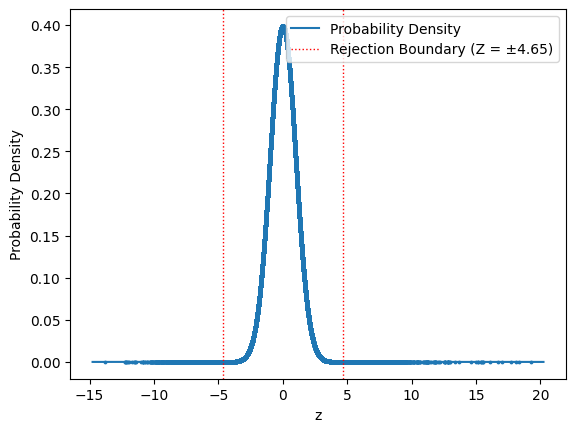

In [8]:
sensor_cols = [col for col in merged.columns if col not in ('time', 'subject')]

# Compute the number of outliers and visualize an example
for col in sensor_cols:
    s = merged[col]
    
    n_chauvenet = chauvenet_count(s, visualize=True)
    
    if n_chauvenet > 0:
        break

Next, a DataFrame is constructed for summary statistics. The outlier detection yields the following result on the dataset.

In [9]:
rows = []
for col in sensor_cols:
    s = merged[col]
    total = len(s)
    n_nan = int(s.isna().sum())
    n_zero = int((s == 0).sum())

    # Compute the number of outliers
    n_chauvenet = chauvenet_count(s)
    
    rows.append({
        'column': col,
        'total': total,
        'missing': n_nan,
        'missing_%': round(100 * n_nan / total, 2),
        'zeros': n_zero,
        'chauvenet_outliers_(c=2)': n_chauvenet,
        'min': round(s.min(), 3) if s.notna().any() else None,
        'max': round(s.max(), 3) if s.notna().any() else None,
    })

summary = pd.DataFrame(rows).set_index('column')
summary

,total,missing,missing_%,zeros,chauvenet_outliers_(c=2),min,max
column,,,,,,,
WatchBarometer_relativeAltitude,302753,30,0.01,1225,0,-8.521,2.008
WatchBarometer_pressure,302753,30,0.01,0,0,1007.940,1009.220
WatchGyroscope_y,302753,3,0.00,2481,3400,-3.429,4.754
WatchGyroscope_z,302753,3,0.00,3356,3205,-5.497,4.932
WatchGyroscope_x,302753,3,0.00,1732,2568,-9.934,11.150
WatchOrientation_qy,302753,5,0.00,0,0,-0.779,0.904
WatchOrientation_qx,302753,5,0.00,0,0,-0.851,0.635
WatchOrientation_yaw,302753,5,0.00,0,0,-3.141,3.141
WatchOrientation_qw,302753,5,0.00,0,0,0.000,0.998


### 1. Domain knowledge outlier removal for HeartRate
A heart rate of 0 bpm is physiologically impossible and indicates a sensor dropout. We replace these with NaN for imputation in Step 3.

In [10]:
merged['HeartRate_bpm'] = merged['HeartRate_bpm'].replace(0, np.nan)

### 2. Chauvenet's criterion for motion sensors
Accelerometer, Gyroscope, Gravity, TotalAcceleration, and Magnetometer produce continuous normally distributed measurements, making Chauvenet appropriate. We use $c=2$ per subject to avoid mixing subject distributions. Flagged values are replaced with NaN for imputation. Orientation is excluded as it is a bounded signal in $[-\pi, \pi]$ and
does not satisfy the normality assumption.

In [11]:
def chauvenet(series: pd.Series, c=2, visualize=False):
    """
    Chauvenet's criterion: Reject a measurement when the
    probability of observing it is less than 1 / (c*N).

    The data is assumed to follow the standard normal
    distribution.
    
    Given a Pandas Series and the parameter c, a positive 
    constant between 1-10 (default 2) specifying the degree 
    of certainty for outlier identification, replace the 
    values of the outliers by NaN values in the Series.
    """
    # Determine the length of the series N, discarding 
    # NaN values, and set the Chauvenet's criterion
    series = series.copy()
    mask = series.notna()
    vals = series[mask]
    N = len(vals)
    if N == 0:
        return series
    criterion = 1.0 / (c * N)

    # Get the original mean and standard deviation
    mu, sigma = vals.mean(), vals.std()
    
    # Get the probability for each data point using the
    # Normal Cumulative Distribution Function.
    prob = stats.norm.cdf(vals, loc=mu, scale=sigma)

    # An outlier is a point where the following holds:
    # 1-P < 1/cN   OR
    # P < 1/cN
    outlier_mask = (1.0 - prob < criterion) | (prob < criterion)

    # Replace the values of the outliers by NaN values
    series[mask] = series[mask].where(~outlier_mask, np.nan)

    return series

# Select the normally distributed columns from the dataset
chauvenet_cols = [col for col in merged.columns if any(
    s in col for s in ['WatchAccelerometer', 'WatchGyroscope', 'WatchGravity',
                       'WatchTotalAcceleration', 'WatchMagnetometer']
)]

# Replace the values of the outliers by NaN values
for col in chauvenet_cols:
    for subj in [1, 2]:
        mask = merged['subject'] == subj
        merged.loc[mask, col] = chauvenet(merged.loc[mask, col])

### 3. Linear interpolation for all remaining missing values
Interpolation is preferred over mean imputation for temporal data as it respects the trend between surrounding measurements. Applied per subject to avoid interpolating across recording boundaries. The `ffill` and `bfill` methods handle edges where interpolation cannot extrapolate.

In [12]:
# Interpolate per subject for NaN values
for col in [c for c in merged.columns if c not in ('time', 'subject')]:
    for subj in [1, 2]:
        mask = merged['subject'] == subj
        merged.loc[mask, col] = (
            merged.loc[mask, col]
            .interpolate(method='linear')
            .ffill()
            .bfill()
        )

print("Missing values remaining after cleaning:")
missing = merged.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

Missing values remaining after cleaning:
None


In case there are missing values remaining, the following cell shows the missing values per subject.

In [13]:
for subj in [1, 2]:
    missing = merged[merged['subject'] == subj].isnull().sum()
    missing = missing[missing > 0]
    print(f"Subject {subj}: {'None' if missing.empty else missing}")

Subject 1: None
Subject 2: None


### Post-cleaning summary
There should be no NaN values remaining. As a final check, the following cell shows a summary.

In [14]:
sensor_cols = [col for col in merged.columns if col not in ('time', 'subject')]

rows = []
for col in sensor_cols:
    s = merged[col]
    n_nan = int(s.isna().sum())
    rows.append({
        'column': col,
        'missing': n_nan,
        'missing_%': round(100 * n_nan / len(s), 2),
    })

post_summary = pd.DataFrame(rows).set_index('column')
print("Post-cleaning missing values:")
print(post_summary[post_summary['missing'] > 0] if post_summary['missing'].any() else "None")

Post-cleaning missing values:
None


### Heart rate cleaning visualization
The plots below show the effect of data cleaning on the heart rate data of subject 1.

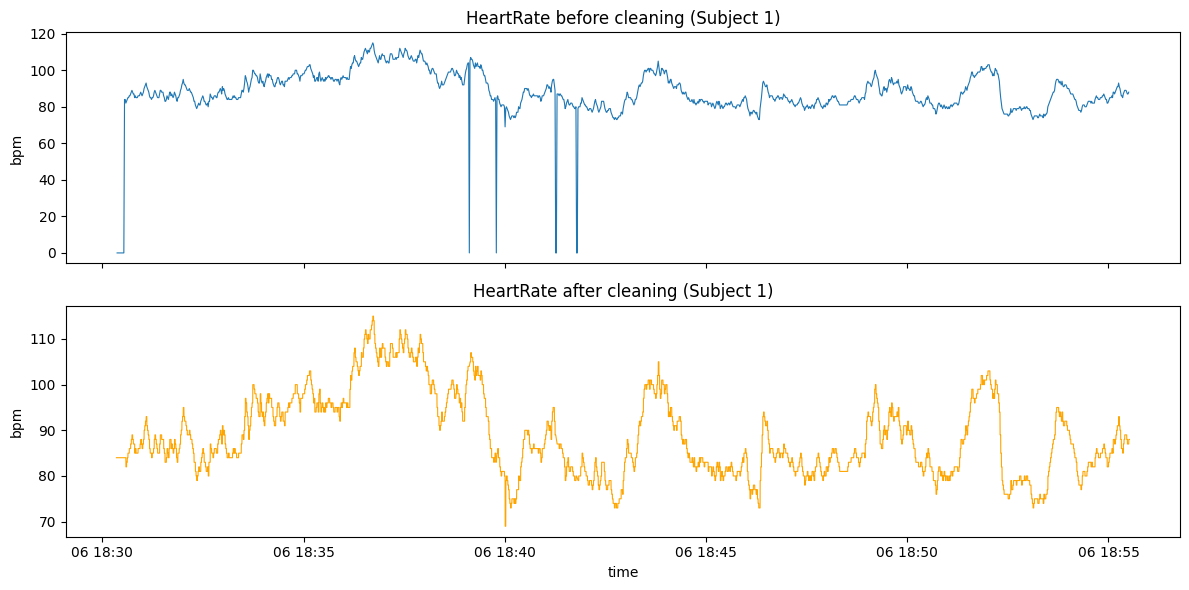

In [15]:
# Get the raw dataset of subject 1
with open('data\subject_1_minutes_25_typing_writing_drawing-2026-06-06_18-30-20.json') as f:
    records = json.load(f)
hr_raw = pd.DataFrame([r for r in records if r['sensor'] == 'HeartRate'])
hr_raw['time'] = pd.to_datetime(pd.to_numeric(hr_raw['time']), unit='ns')
hr_raw['bpm'] = pd.to_numeric(hr_raw['bpm'])
hr_raw = hr_raw.set_index('time').sort_index()

# Get the cleaned dataset for subject 1
subj1 = merged[merged['subject'] == 1].set_index('time')

# Create the figure
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Create the plot of the raw dateset for subject 1
axes[0].plot(hr_raw.index, hr_raw['bpm'], linewidth=0.8)
axes[0].set_title('HeartRate before cleaning (Subject 1)')
axes[0].set_ylabel('bpm')

# Create the plot of the cleaned dateset for subject 1
axes[1].plot(subj1.index, subj1['HeartRate_bpm'], linewidth=0.8, color='orange')
axes[1].set_title('HeartRate after cleaning (Subject 1)')
axes[1].set_ylabel('bpm')
axes[1].set_xlabel('time')

# Show and save the figure
plt.tight_layout()
plt.savefig('figures\heartrate_before_after.png', dpi=150)
plt.show()